In [3]:
import os
print(os.getcwd())

c:\Users\kallu\OneDrive\Desktop\ML - 0027 - Human Development Ind\Training


In [4]:
import os
print(os.listdir())

['HumDevIndex.ipynb', 'train.py']


In [2]:
# 1. Environment Setup & Data Collection
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
import pickle

# Load dataset
df = pd.read_csv("../Dataset/HDI.csv.CSV")

# Clean columns of trailing whitespaces
df.columns = df.columns.str.strip()
print("Dataset loaded! Here are your available columns:")
print(df.columns.tolist())

Dataset loaded! Here are your available columns:
['ISO3', 'Country', 'Human Development Groups', 'UNDP Developing Regions', 'HDI Rank (2021)', 'Human Development Index (1990)', 'Human Development Index (1991)', 'Human Development Index (1992)', 'Human Development Index (1993)', 'Human Development Index (1994)', 'Human Development Index (1995)', 'Human Development Index (1996)', 'Human Development Index (1997)', 'Human Development Index (1998)', 'Human Development Index (1999)', 'Human Development Index (2000)', 'Human Development Index (2001)', 'Human Development Index (2002)', 'Human Development Index (2003)', 'Human Development Index (2004)', 'Human Development Index (2005)', 'Human Development Index (2006)', 'Human Development Index (2007)', 'Human Development Index (2008)', 'Human Development Index (2009)', 'Human Development Index (2010)', 'Human Development Index (2011)', 'Human Development Index (2012)', 'Human Development Index (2013)', 'Human Development Index (2014)', 'Human 

In [4]:
print(df.columns.tolist())

['ISO3', 'Country', 'Human Development Groups', 'UNDP Developing Regions', 'HDI Rank (2021)', 'Human Development Index (1990)', 'Human Development Index (1991)', 'Human Development Index (1992)', 'Human Development Index (1993)', 'Human Development Index (1994)', 'Human Development Index (1995)', 'Human Development Index (1996)', 'Human Development Index (1997)', 'Human Development Index (1998)', 'Human Development Index (1999)', 'Human Development Index (2000)', 'Human Development Index (2001)', 'Human Development Index (2002)', 'Human Development Index (2003)', 'Human Development Index (2004)', 'Human Development Index (2005)', 'Human Development Index (2006)', 'Human Development Index (2007)', 'Human Development Index (2008)', 'Human Development Index (2009)', 'Human Development Index (2010)', 'Human Development Index (2011)', 'Human Development Index (2012)', 'Human Development Index (2013)', 'Human Development Index (2014)', 'Human Development Index (2015)', 'Human Development Ind

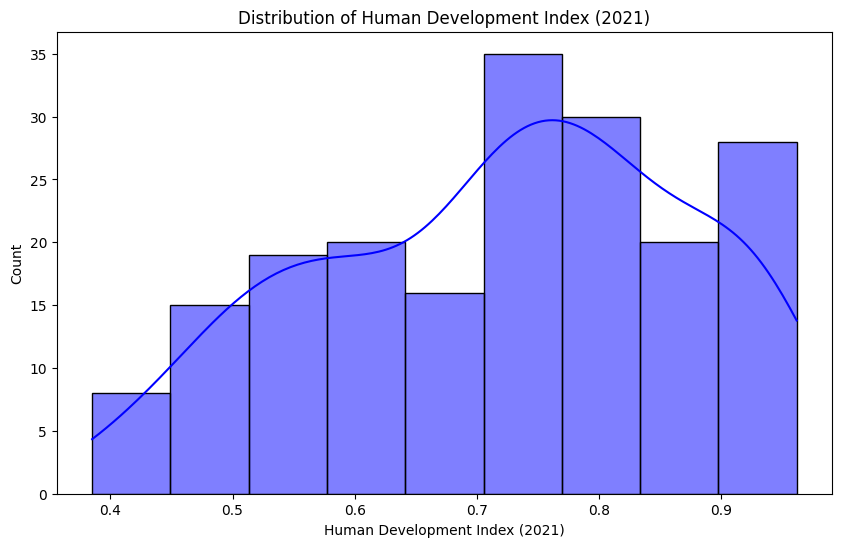

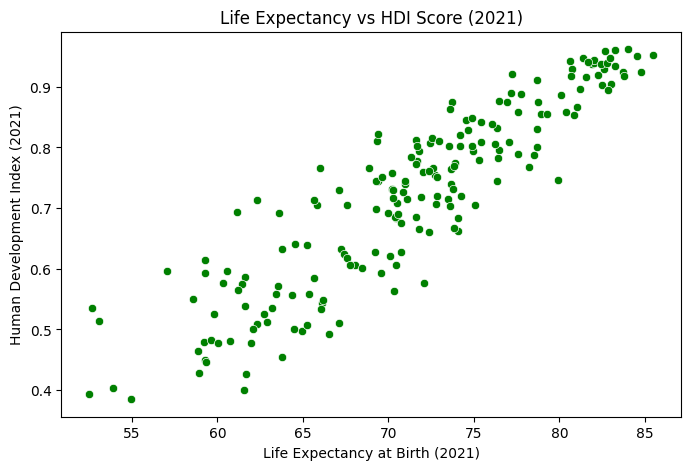

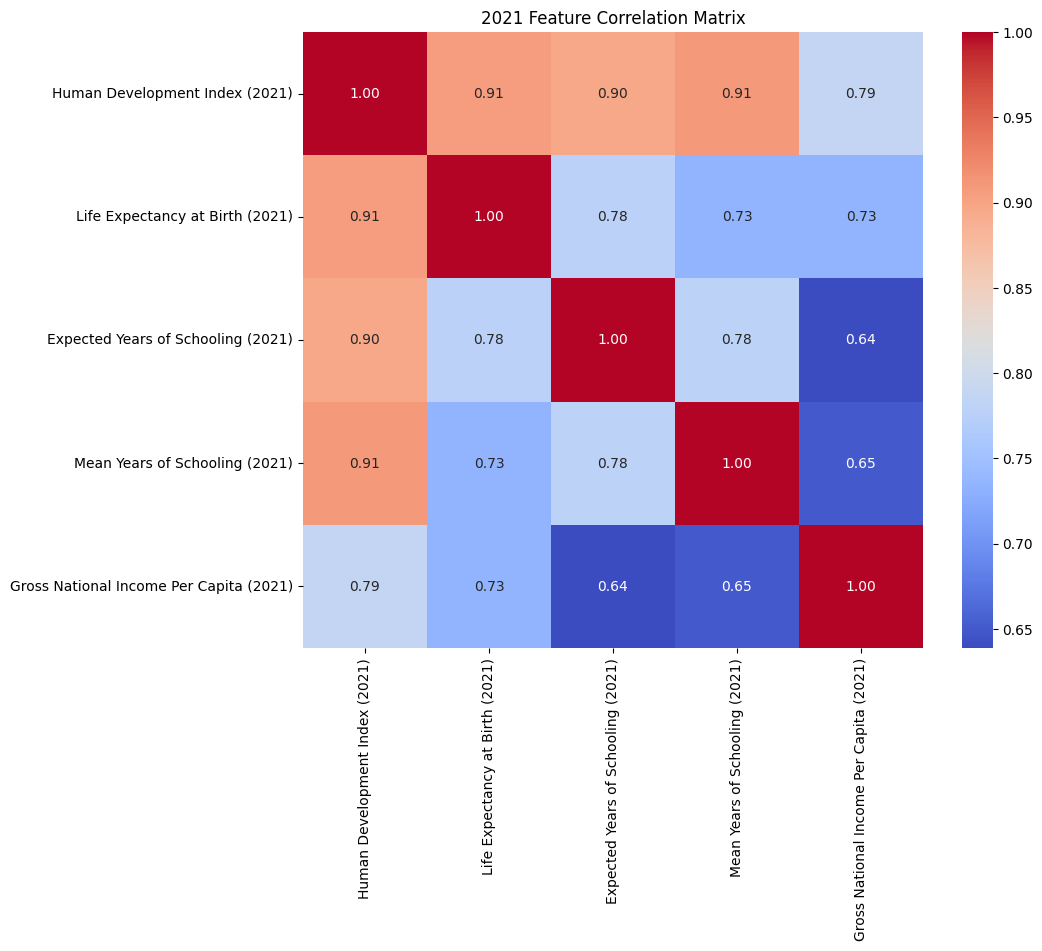

In [5]:
# # 3. Data Visualization & Analysis (EDA)
plt.figure(figsize=(10, 6))

# A. Distribution Plot of the Target (HDI Score for 2021)
sns.histplot(df['Human Development Index (2021)'], kde=True, color='blue')
plt.title('Distribution of Human Development Index (2021)')
plt.show()

# B. Scatter Plot (Life Expectancy 2021 vs HDI 2021)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Life Expectancy at Birth (2021)'], y=df['Human Development Index (2021)'], color='green')
plt.title('Life Expectancy vs HDI Score (2021)')
plt.show()

# C. Correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
# Filter columns relating to 2021 for a clean correlation check
cols_2021 = [
    'Human Development Index (2021)', 
    'Life Expectancy at Birth (2021)', 
    'Expected Years of Schooling (2021)', 
    'Mean Years of Schooling (2021)', 
    'Gross National Income Per Capita (2021)'
]
sns.heatmap(df[cols_2021].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('2021 Feature Correlation Matrix')
plt.show()

In [6]:
# 4. Data Preprocessing & Feature Engineering

# Fill missing values with column means
df.fillna(df.mean(numeric_only=True), inplace=True)

# Encode Country Name text strings into numbers
le = LabelEncoder()
df['Country_Encoded'] = le.fit_transform(df['Country'])

# Select features (Independent) and target (Dependent) using 2021 values
X = df[['Country_Encoded', 
        'Life Expectancy at Birth (2021)', 
        'Expected Years of Schooling (2021)', 
        'Mean Years of Schooling (2021)', 
        'Gross National Income Per Capita (2021)']]

y = df['Human Development Index (2021)']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data preprocessed and split successfully using 2021 metrics!")

Data preprocessed and split successfully using 2021 metrics!


C:\Users\kallu\AppData\Local\Temp\ipykernel_24148\1792542175.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Country_Encoded'] = le.fit_transform(df['Country'])


In [7]:
# 5. Machine Learning Model Building & 6. Serialization

# Fit Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Performance Testing
predictions = model.predict(X_test)
print("--- Model Performance Testing ---")
print("R-Squared Score:", metrics.r2_score(y_test, predictions))
print("Mean Absolute Error:", metrics.mean_absolute_error(y_test, predictions))

# Save the trained model file directly into the Flask folder
with open('../Flask/HDI.pkl', 'wb') as file:
    pickle.dump(model, file)

print("\nSuccess! HDI.pkl model file generated inside your Flask directory.")

--- Model Performance Testing ---
R-Squared Score: 0.9584514436617347
Mean Absolute Error: 0.02154801240035242

Success! HDI.pkl model file generated inside your Flask directory.
